# Clustering

In [61]:
import pandas as pd
from pathlib import Path
import numpy as np
import json
ROOT = Path.cwd().parent
motor='DATA_MODEL_Dev/Motor_data_models.csv'
subject='DATA_MODEL_Dev/Subject_data_models.csv'
data_split='DATA_RAW_MODELS/Data_split.json'

with open(ROOT/data_split, "r", encoding="utf-8") as archivo:
    data_subjects = json.load(archivo)

subjects_train=data_subjects['Train_80']
subjects_test=data_subjects['Test_20']


# Data For Clustring

In [62]:
X_subject=pd.read_csv(ROOT/subject)

X_subject.drop(columns=['MDS-UPDRS Part IV Total Score','MDS-UPDRS Total Score','UPDRS_III_ProgressionType','RBD at Enrollment','Birth Date'],inplace=True)
X_motor=pd.read_csv(ROOT/motor)

X_subject=X_subject.merge(X_motor[['subject_visit','UPDRS_I_Class','UPDRS_II_Class','UPDRS_III_Class','UPDRS_IV_Class','Δ UPDRS_III_1Y','3.21 HOEHN AND YAHR STAGE']],on='subject_visit',how='inner')

lower = X_subject['Δ UPDRS_III_1Y'].quantile(0.025)
upper = X_subject['Δ UPDRS_III_1Y'].quantile(0.972)

X_subject = X_subject[
    (X_subject['Δ UPDRS_III_1Y'] >= lower) &
    (X_subject['Δ UPDRS_III_1Y'] <= upper)
]

X_subject['Other_Mutations']=X_subject[['SNCA Mutation at Enrollment','Parkin Mutation at Enrollment']].apply(
    lambda x: 1 if ( x['SNCA Mutation at Enrollment']==1 or x['Parkin Mutation at Enrollment']==1 ) else 0, axis=1)

X_subject.drop(columns=['SNCA Mutation at Enrollment','Parkin Mutation at Enrollment','Ortostatic_Hypotension','Δ UPDRS_III_1Y'],inplace=True)

X_subject["Education_Type"] = X_subject["Education_Years"].apply(
    lambda years:
        "Low" if years < 12 else
        "Medium" if years == 12 else
        "Medium-High" if 13 <= years <= 15 else
        "High" if 16 <= years <= 19 else
        "Very High"
)

X_subject["BMI_Category"] = X_subject["BMI"].apply(
    lambda x: "Normal" if x < 25 else
              ("OverWeight" if x < 30 else "Obese")
)

X_subject=X_subject.loc[X_subject['subject_visit'].isin(subjects_train), :]
X_subject.drop(columns=['subject_visit'],inplace=True)

## Data Type

In [63]:
X_subject

,LRRK2 Mutation at Enrollment,GBA Mutation at Enrollment,Sex of participant at birth,Identify self as White,Education_Years,AGE_AT_VISIT,MDS-UPDRS Part I (Patient Questionnaire) Total Score,MDS-UPDRS Part II Total Score,MDS-UPDRS Part III Total Score,BMI,Age_Type,UPDRS_I_Class,UPDRS_II_Class,UPDRS_III_Class,UPDRS_IV_Class,3.21 HOEHN AND YAHR STAGE,Other_Mutations,Education_Type,BMI_Category
1,0,0,1,1,19.0,68.4,2,7.0,23,22.985398,0,0,0,0,0,2,0,High,Normal
2,0,0,0,1,18.0,67.0,6,5.0,14,31.130098,0,0,0,0,0,1,0,High,Obese
4,0,0,1,1,16.0,63.2,6,5.0,14,26.481633,0,0,0,0,0,2,0,High,OverWeight
8,0,0,1,1,13.0,56.2,4,11.0,16,25.381469,1,0,0,0,0,1,0,Medium-High,OverWeight
9,0,1,0,1,12.0,45.0,3,8.0,25,20.956607,1,0,0,0,1,2,0,Medium,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
904,1,0,1,1,19.0,52.7,6,14.0,16,25.535446,1,0,1,0,0,2,0,High,OverWeight
906,0,1,1,1,17.0,60.6,14,12.0,20,31.656357,1,1,0,0,0,2,0,High,Obese
907,1,0,1,1,24.0,61.6,5,8.0,16,21.028571,0,0,0,0,1,2,0,Very High,Normal
908,1,0,1,1,21.0,68.3,16,12.0,32,27.304688,0,1,0,0,0,2,0,Very High,OverWeight


In [64]:
X_subject[['LRRK2 Mutation at Enrollment','GBA Mutation at Enrollment','Other_Mutations',
           'Sex of participant at birth','Identify self as White','Age_Type']]=X_subject[['LRRK2 Mutation at Enrollment','GBA Mutation at Enrollment','Other_Mutations',
           'Sex of participant at birth','Identify self as White','Age_Type']].astype('category')

X_subject[['Education_Years','AGE_AT_VISIT','MDS-UPDRS Part I (Patient Questionnaire) Total Score',
           'MDS-UPDRS Part II Total Score','MDS-UPDRS Part III Total Score','BMI','3.21 HOEHN AND YAHR STAGE']]=X_subject[['Education_Years','AGE_AT_VISIT','MDS-UPDRS Part I (Patient Questionnaire) Total Score','MDS-UPDRS Part II Total Score','MDS-UPDRS Part III Total Score','BMI','3.21 HOEHN AND YAHR STAGE']].astype('float64')

X_subject.info()




<class 'pandas.core.frame.DataFrame'>
Index: 697 entries, 1 to 909
Data columns (total 19 columns):
 #   Column                                                Non-Null Count  Dtype   
---  ------                                                --------------  -----   
 0   LRRK2 Mutation at Enrollment                          697 non-null    category
 1   GBA Mutation at Enrollment                            697 non-null    category
 2   Sex of participant at birth                           697 non-null    category
 3   Identify self as White                                697 non-null    category
 4   Education_Years                                       697 non-null    float64 
 5   AGE_AT_VISIT                                          697 non-null    float64 
 6   MDS-UPDRS Part I (Patient Questionnaire) Total Score  697 non-null    float64 
 7   MDS-UPDRS Part II Total Score                         697 non-null    float64 
 8   MDS-UPDRS Part III Total Score                        6

## FAMD Data

In [71]:
import prince 
famd = prince.FAMD(
    n_components=11,    
    n_iter=11,
    copy=True,
    check_input=True,
    engine="sklearn",   
    random_state=42
)

famd = famd.fit(X_subject)
famd.eigenvalues_summary



,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,10.515,10.21%,10.21%
1,9.573,9.29%,19.50%
2,7.966,7.73%,27.24%
3,7.875,7.65%,34.88%
4,7.517,7.30%,42.18%
5,6.849,6.65%,48.83%
6,6.374,6.19%,55.02%
7,5.951,5.78%,60.80%
8,5.875,5.70%,66.50%


In [72]:
famd.plot(
    X_subject,
    x_component=0,
    y_component=1
)

alt.LayerChart(...)

In [73]:
famd.column_contributions_.style.format('{:.0%}')

component,0,1,2,3,4,5,6,7,8,9,10
variable,,,,,,,,,,,
Education_Years,0%,2%,2%,3%,0%,0%,0%,0%,1%,0%,1%
AGE_AT_VISIT,0%,0%,5%,2%,0%,0%,0%,0%,0%,0%,0%
MDS-UPDRS Part I (Patient Questionnaire) Total Score,4%,0%,0%,0%,0%,0%,0%,0%,0%,0%,1%
MDS-UPDRS Part II Total Score,5%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%
MDS-UPDRS Part III Total Score,2%,1%,1%,0%,1%,0%,0%,0%,0%,0%,0%
BMI,0%,1%,0%,3%,3%,0%,0%,0%,1%,2%,1%
3.21 HOEHN AND YAHR STAGE,1%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%
Age_Type,0%,0%,6%,2%,0%,1%,0%,0%,0%,0%,0%
BMI_Category,0%,2%,2%,4%,5%,1%,1%,0%,5%,2%,3%


In [74]:
X_mca=famd.row_coordinates(X_subject)

# Models For MCA Data

## 1. K-means Baseline

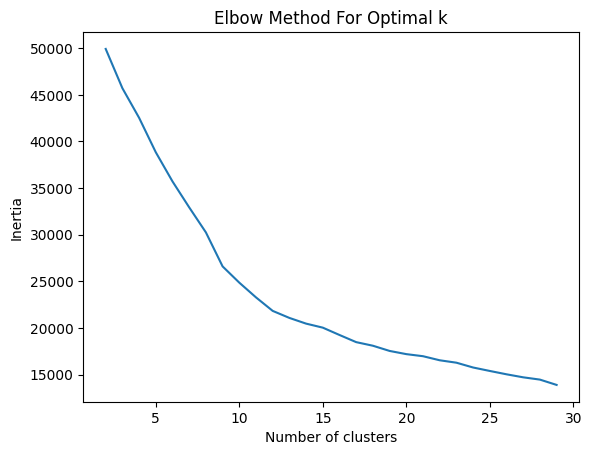

In [75]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k = range(2,30)
inertia = []

for i in k:
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(X_mca)
    inertia.append(km.inertia_)

plt.plot(k, inertia)
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()


## 2. GMM

In [76]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score



# ==========================
# 2) Probar diferentes K
# ==========================
Ks = [2, 3, 4,5,6,7,8,9,10]

results = []

for k in Ks:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        reg_covar=1e-5,
        random_state=42
    )

    gmm.fit(X_mca)

    bic = gmm.bic(X_mca)
    aic = gmm.aic(X_mca)

    labels = gmm.predict(X_mca)
    sizes = np.bincount(labels)


    results.append({
        "K": k,
        "BIC": bic,
        "AIC": aic,
       
        "cluster_sizes": sizes
    })

# ==========================
# 3) Ver resultados
# ==========================
results_df = pd.DataFrame(results)
results_df

,K,BIC,AIC,cluster_sizes
0,2,34333.056579,33628.304841,"[576, 121]"
1,3,32200.180497,31140.779496,"[441, 62, 194]"
2,4,27490.595131,26076.544868,"[235, 62, 212, 188]"
3,5,28469.843113,26701.143588,"[74, 50, 143, 257, 173]"
4,6,26521.382261,24398.033474,"[82, 50, 220, 141, 111, 93]"
5,7,27463.225087,24985.227039,"[93, 47, 208, 141, 111, 82, 15]"
6,8,27693.419636,24860.772325,"[96, 110, 134, 112, 24, 15, 49, 157]"
7,9,24911.785912,21724.489339,"[64, 102, 134, 100, 24, 15, 49, 162, 47]"
8,10,23004.861177,19462.915342,"[86, 84, 136, 47, 24, 15, 44, 169, 36, 56]"
